In [34]:
#import minimo propuesto:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import urllib
import seaborn as sns
import pandas as pd
import scipy.sparse as sparse

## P1: Elección y descripción de la red


Se escogió la red de transacciones de Bitcoin OTC (http://konect.cc/networks/soc-sign-bitcoinotc/)  
Bitcoin OTC (https://bitcoin-otc.com/) es una plataforma en línea que facilita el comercio directo de Bitcoins entre personas, operando al margen de plataformas de intercambio centralizadas, como Binance o Coinbase.
* **Contexto de recopilación:** Dado que las transacciones de Bitcoin son anónimas, la plataforma implementó un sistema de reputación ("web of trust"). **citar el link donde esta ubicada la base de datos de la web of trust**
* **Por qué se escogieron los datos:** A diferencia de las redes convencionales, esta es una red dirigida y ponderada (las conexiones poseen un valor numérico que mide la intensidad de la relación). Además, es una red con signo, que documenta tanto el nivel de confianza como desconfianza. Esto permite usar PageRank para rastrear estructuras criminales en lugar de solo medir popularidad.
* **Qué representan los nodos:** Cada nodo representa a un usuario individual (comprador o vendedor) registrado en la plataforma.
* **Qué representan las aristas:** Las aristas representan la evaluación de un usuario sobre otro. Al ser dirigidas, muestran la dirección de la acción (el usuario A evalúa al usuario B). Al ser ponderadas, asignan una magnitud a esa relación, utilizando una escala del -10 (estafa/desconfianza total) al +10 (confianza total). También incluyen la marca de tiempo exacta de la calificación.  

| Estadística | Fórmula / Símbolo | Valor (Bitcoin OTC) |
| --- | --- | --- |
| **Número de nodos** | $n$ | 5,881 |
| **Número de aristas** | $m$ | 35,592 |
| **Grado de entrada medio** | $\bar{d}^{\text{in}}$ | 6.05 |
| **Grado de salida medio** | $\bar{d}^{\text{out}}$ | 6.05 |
| **Nodo de mayor grado de entrada** | - | [ID del Nodo a calcular] |
| **Densidad de la red** | $\frac{m}{n(n-1)}$ | 0.001029 |
| **Cantidad de nodos colgantes** (sin aristas de salida) | - | [Cantidad a calcular] |

*(Nota: En una red dirigida, el grado de entrada medio y el grado de salida medio son iguales, ya que cada arista que sale de un nodo entra necesariamente en otro. La densidad se calculó asumiendo el máximo de conexiones posibles sin contar bucles).*

## P2

**Pregunta:**
¿Es posible identificar a los cabecillas o actores centrales del fraude dentro de una plataforma de transacciones anónimas aplicando el algoritmo de PageRank de manera inversa sobre las interacciones de máxima desconfianza?

**Hipótesis:**
Nuestra hipótesis plantea que los estafadores sofisticados en la red Bitcoin OTC no operan de forma aislada, sino que interactúan y se califican negativamente entre sí para fingir legitimidad y distanciarse. Por lo tanto, al aislar los pesos negativos de la red e invertir la dirección de las aristas, un cálculo de PageRank revelará una jerarquía oculta donde los nodos con mayor "rango de desconfianza" corresponderán a los mayores estafadores o ejes centrales del submundo criminal en la plataforma.

## Seccion p3

Hacer analisis (propuesta, usar las clases como referente), lo que se nos pide es:


(a) Gr´afico de la distribuci´on del grado de entrada y del grado de salida.
(b) Identificaci´on y conteo de los nodos colgantes (nodos con grado de salida
cero). Expliquen por qu´e su presencia es problem´atica para el PageRank y
c´omo se resuelve con la matriz columna-estoc´astica S.
(c) Gr´afico o tabla con los 10 nodos de mayor grado de entrada y los 10 nodos de
mayor grado de salida. Si los nodos tienen nombres o etiquetas, incl´uyanlos.
(d) Comentario sobre si la red parece ser fuertemente conexa o si existen com-
ponentes aisladas. Pueden usar la condici´on de que la Matriz de Google G
es siempre irreducible independientemente de la estructura del grafo subya-
cente


## a ) Grafico de la distribucion del grado de entrada y del grado de salida

In [35]:
#abrir el grafo

RUTA_GRAFO = "grafo/soc-sign-bitcoinotc/out.soc-sign-bitcoinotc"
G = nx.read_edgelist(RUTA_GRAFO , create_using=nx.DiGraph() , comments= "%" , data=[('weight', float), ('timestamp', float)] )

print(f"el frafo tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas")



el frafo tiene 5881 nodos y 35592 aristas


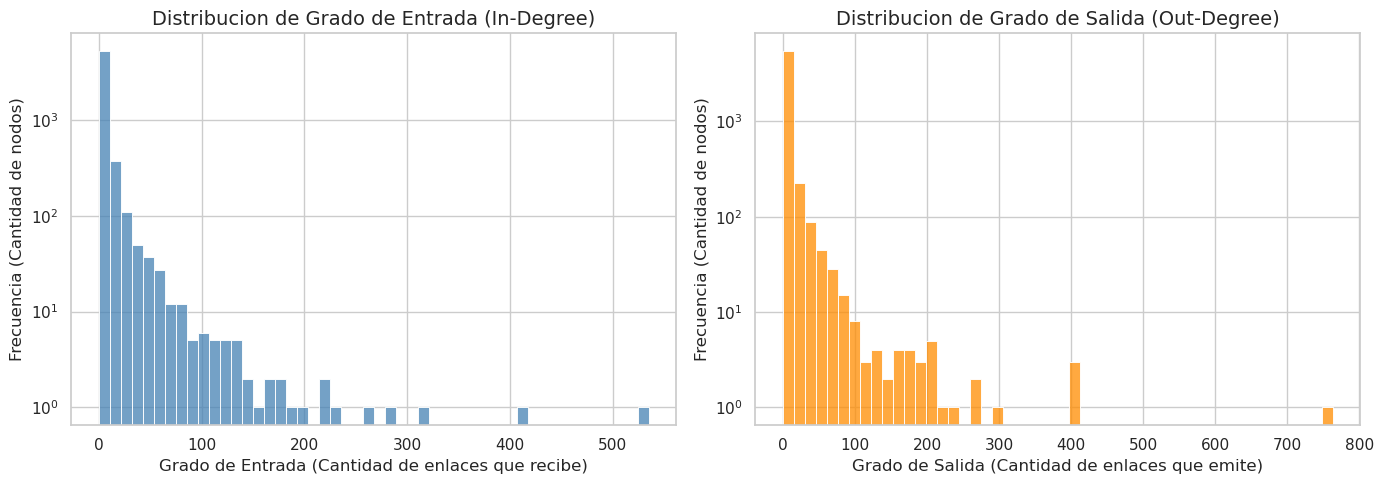

In [36]:
input_degre = [deg for node , deg in G.in_degree()]
output_degre = [deg for node , deg in G.out_degree()]

#grafico distribucion

sns.set_theme(style = "whitegrid")
fig , axes = plt.subplots(1 , 2 , figsize = (14 , 5))

sns.histplot(input_degre, bins=50, ax=axes[0], color='steelblue', kde=False)
axes[0].set_title("Distribucion de Grado de Entrada (In-Degree)", fontsize=14)
axes[0].set_xlabel("Grado de Entrada (Cantidad de enlaces que recibe)", fontsize=12)
axes[0].set_ylabel("Frecuencia (Cantidad de nodos)", fontsize=12)
axes[0].set_yscale('log') 
sns.histplot(output_degre, bins=50, ax=axes[1], color='darkorange', kde=False)
axes[1].set_title("Distribucion de Grado de Salida (Out-Degree)", fontsize=14)
axes[1].set_xlabel("Grado de Salida (Cantidad de enlaces que emite)", fontsize=12)
axes[1].set_ylabel("Frecuencia (Cantidad de nodos)", fontsize=12)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## b ) dentificacion y conteo de los nodos colgantes (nodos con grado de salida cero). Expliquen por que su presencia es problem ́atica para el PageRank ycomo se resuelve con la matriz columna-estocastica S.

In [37]:
nodos_colgantes = [nodo for nodo , output_grados in G.out_degree() if output_grados == 0]

cantidad_colgantes = len(nodos_colgantes)
total_nodos = (G.number_of_nodes())
porcentajes = round((cantidad_colgantes / total_nodos) * 100  , 2)

print(f"Total de nodos en el grafo: {total_nodos}")
print(f"Cantidad de nodos colgantes: {cantidad_colgantes}")
print(f"porcentaje de nodos colgantes: {porcentajes} ")

Total de nodos en el grafo: 5881
Cantidad de nodos colgantes: 1067
porcentaje de nodos colgantes: 18.14 


### ¿Porque la precencia de nodos colgantes es problematica para la creacion de la page rank?

Page Rank modela la navegación por medio de "caminos aleatorios" buscando analizar su convergencia, en este sentido , si nuestro "Caminante aleatorio" llega a un nodo colgante (sin aristas de salida) se quedara atrapado, luego esto implica que la matriz no converge a nada. Por otro lado, si lo analizamos en términos matriciales, se tiene que la columna asociada a ese nodo en la matriz de hipervínculos $H$ poseerá únicamente 0, y por ende no será estocástica y haciendo que el algoritmo de iteración de potencias pierda probabilidades con cada iteración, impidiendo una convergencia a alguna distribución válida

### ¿Cómo se resuelve con la matriz columna-estocástica?

La solución para este problema es "Forzar" a que la matriz sea estocástica. Para esto vamos a sustituir la columna llena de 0 por vectores uniformes donde su entrada vale $1/n$ con n como la cantidad total de nodos. Esto significa que cuando nuestro elemento "caminante" llegue al nodo problemático, se teletransporta aleatoriamente a cualquier otro con cualquier otro nodo con igual probabilidad, permitiendo su convergencia y que la nueva matriz S sume a 1

## C ) Gráfico o tabla con los 10 nodos de mayor grado de entrada y los 10 nodos de mayor grado de salida. Si los nodos tienen nombres o etiquetas, inclúyanlos.

_________________ Top 10 nodos con mayor grado de entrada _________________


,nodo (ID),Grado de entrada
0,24,535
1,2572,412
2,1786,311
3,1981,279
4,946,264
5,4,226
6,4072,222
7,11,216
8,4090,203
9,8,191


_________________ Top 10 nodos con mayor grado de Salida _________________


,nodo (ID),Grado de Salida
0,24,763
1,2572,406
2,1786,404
3,2072,397
4,1981,293
5,946,264
6,4072,264
7,11,232
8,4,215
9,3033,212


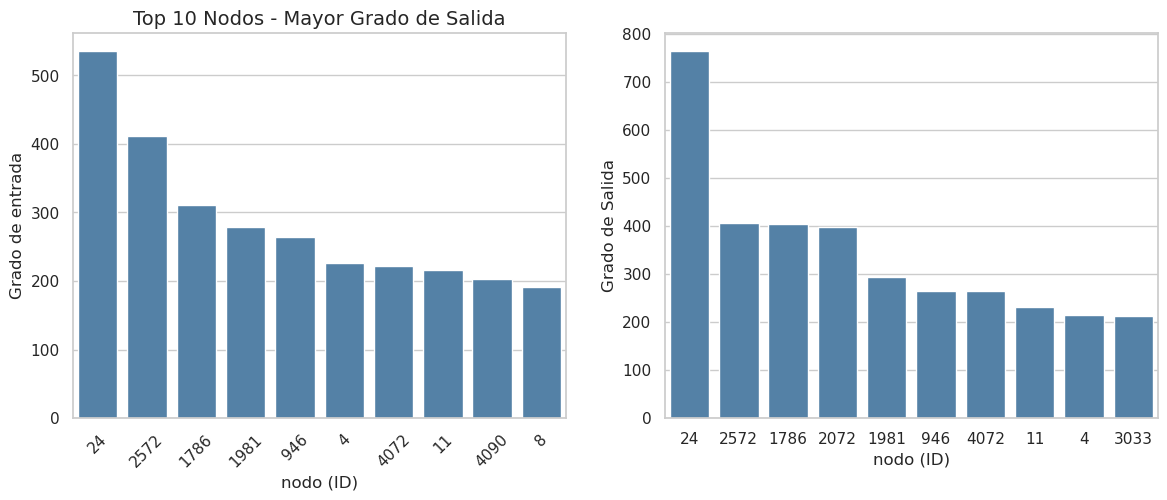

In [38]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

top_10_in = sorted(in_degree.items() , key = lambda x : x[1] , reverse=True)[:10]
top_10_out = sorted(out_degree.items() , key = lambda x : x[1] , reverse=True)[:10]

df_in = pd.DataFrame(top_10_in , columns=["nodo (ID)" , "Grado de entrada"])
df_out = pd.DataFrame(top_10_out , columns=["nodo (ID)" , "Grado de Salida"])
#tabla
print("_________________ Top 10 nodos con mayor grado de entrada _________________")
display(df_in)


print("_________________ Top 10 nodos con mayor grado de Salida _________________")
display(df_out)

#grafico
sns.set_theme(style="whitegrid")
fig , axes = plt.subplots(1 , 2 , figsize=(14 , 5))

#grafico input
sns.barplot(data = df_in , x = "nodo (ID)" , y = "Grado de entrada" , ax = axes[0] , color='steelblue', order = df_in["nodo (ID)"])
axes[0].set_title("Top 10 Nodos - Mayor Grado de Entrada", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
#grafico output
sns.barplot(data = df_out , x = "nodo (ID)" , y = "Grado de Salida" , ax = axes[1] , color='steelblue', order = df_out["nodo (ID)"])
axes[0].set_title("Top 10 Nodos - Mayor Grado de Salida", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)



In [39]:
ids_in = set(df_in['nodo (ID)'])
ids_out = set(df_out['nodo (ID)'])

nodos_comunes = ids_in.intersection(ids_out)
print(f"Los IDs de los nodos que aparecen en ambos Top 10 son: {nodos_comunes}")
print("luego podemos usar esto para verficar si estos elemtynos son los nodos con confianaza en la red de bitcoin  btw")

Los IDs de los nodos que aparecen en ambos Top 10 son: {'1786', '946', '4072', '4', '11', '1981', '24', '2572'}
luego podemos usar esto para verficar si estos elemtynos son los nodos con confianaza en la red de bitcoin  btw


## d ) Analizar conexidad de la red de bitcoin

In [40]:
es_conexa = nx.is_strongly_connected(G)

print(f"¿La red es fuertemente conexa? : {es_conexa}")

conexiones_conexas = nx.number_strongly_connected_components(G)
print(f"El numero de componentes que son fuertemente conexas son : {conexiones_conexas}")

componentes_fuertes = list(nx.strongly_connected_components(G))
tamanos_scc = [len(c) for c in componentes_fuertes]
tamanos_scc.sort(reverse= True)

print(f"el tamaño de la componente fuertemente conexa mas grande es : {tamanos_scc[0]} nodos")
print(f"cantidad de componentes compuetas por un solo nodo aislado : {tamanos_scc.count(1)}")
#analisis conexa si ignoramos direccion flechas
es_conexa_debil = nx.is_weakly_connected(G)
num_wcc = nx.number_weakly_connected_components(G)
print(f"¿la red es debilmente conexa (ignorando la direccion de los nodos)? : {es_conexa} ")
print(f"numero de componentes debilmente conexas : {num_wcc}" )


¿La red es fuertemente conexa? : False
El numero de componentes que son fuertemente conexas son : 1144
el tamaño de la componente fuertemente conexa mas grande es : 4709 nodos
cantidad de componentes compuetas por un solo nodo aislado : 1121
¿la red es debilmente conexa (ignorando la direccion de los nodos)? : False 
numero de componentes debilmente conexas : 4


Se puede notar que la red no es ni fuertemente conexa ni débilmente conexa, respecto a que la red no sea fuertemente conexa, esto era esperable, puesto que en la vida real es relativamente común que ciertas entidades depositen o hagan mucha transacción con nodos específicos y que esto no suceda en el caso contrario, a sí mismo que la red no sea débilmente conexa se puede explicar con la variabilidad y la forma en la que se hacen las transacciones, para ser débilmente conexa se esperaría que las transacciones se hagan de ambos lados (que 2 nodos se transfieran dinero de forma constante) cosa que no es esperable en la vida real

## p4

Crear la google matriz

(ejemplo en clase y tngo apuntes del mismo , cualquier cosa me preguntan)





In [ ]:
#P4 (a) Construccion de la matriz de hipervinculos

nodos = list(G.nodes())
n = len(nodos)
nodos_idx = {nodo : i for i, nodo in enumerate(nodos)}
H_sparse = sparse.lil_matrix((n , n ))

for j_nodo in nodos:
    j = nodos_idx[j_nodo]
    out_deg = G.out_degree(j_nodo)

    if out_deg > 0:
        for i_nodo in G.successors(j_nodo):
            i = nodos_idx[i_nodo]
            H_sparse[i , j ] = 1.0 / out_deg
#pasar a matriz
H = H_sparse.toarray()

column_suma_H = H.sum(axis = 0)
columnas_cero = np.where(column_suma_H == 0)[0]

print(f"matriz h construida con las dimenciones {H.shape}")
print(f"Columnas cero encontradas : {len(columnas_cero)}")


-------- Parte (a) --------
matriz h construida con las dimenciones (5881, 5881)
Columnas cero encontradas : 1067


In [45]:
#p4 (b) construccion matriz estocastica S

a = np.zeros(n)
for j_nodo in nodos:
    j = nodos_idx[j_nodo]
    if G.out_degree(j_nodo) == 0 :
        a[j] = 1

S = H + (1.0 / n) * np.outer(np.ones(n) , a) #https://numpy.org/doc/stable/reference/generated/numpy.outer.html
columnas_suma_s = S.sum(axis = 0)
sumas_correctas= np.allclose(columnas_suma_s , 1.0) #allclose revisa si so similares en una distancia epsilon
print(f"todas las columnas de S suman 1 ? {sumas_correctas}" )

print(f"Suma mínima observada en columnas de S: {columnas_suma_s.min()}")
print(f"Suma máxima observada en columnas de S: {columnas_suma_s.max()}")


todas las columnas de S suman 1 ? True
Suma mínima observada en columnas de S: 0.9999999999999039
Suma máxima observada en columnas de S: 1.000000000000013


poodemos notar que el margen de error encontrado se corresponde con errores asociados al computo de numeros de coma flotante, y por tanto son validos con nuestros calculos

## p5 

Calcular la page rank de esta misma por iteraciones de potencia implementando el algoritmo de la iteracion de potencias ()

## p6

crear el page rank y analizarfo con el grado de entrada, 

## p7

Interpretar los resultados ,explicar como funcionea, que significa los datos

hacer un subgrado por los 50 nodos mas importantes , si existen ciertos atributos a cada grafo , ponerlos tambien

si la red tiene nodos dedistintas categorias, clasificarlos en cada una

## p8

Explicar los resultados , las diferencias en la hipotesis , sus limitacio nes, resultados y demas

se deben de cumplir minimamente con las siguientes preguntas


¿La pregunta que formularon qued´o respondida con el an´alisis? ¿En qu´e
medida?
¿Qu´e limitaciones tiene PageRank para la red elegida? Por ejemplo: ¿tiene
sentido el modelo de marcha aleatoria? ¿los nodos colgantes son frecuentes
y afectan el resultado? ¿la red es demasiado densa o demasiado dispersa
para que PageRank sea informativo?
¿Qu´e preguntas nuevas surgieron del an´alisis que no anticiparon al co-
mienzo?
Si tuvieran que explicar el resultado principal a alguien sin conocimientos
t´ecnicos, ¿c´omo lo describir´ıan?

## se le pidio a una IA que de este mini check list de lo que debemos hacer

### Checklist de Entregables del Proyecto

* **P1: Elección y descripción de la red**
* [ ] Seleccionar una red dirigida de KONECT (mínimo 500 nodos y 2000 aristas).


* [ ] Describir el contexto, qué representan nodos/aristas y justificar la elección.


* [ ] Incluir tabla de estadísticas: $n$, $m$, $d^{in}$, $d^{out}$, nodo de mayor $d^{in}$, densidad y nodos colgantes.




* **P2: Pregunta e hipótesis inicial**
* [ ] Formular una pregunta concreta anclada al contexto de la red.


* [ ] Proponer una hipótesis sobre qué nodos tendrán mayor PageRank y justificarla (basada en dominio o exploración previa).




* **P3: Análisis exploratorio**
* [ ] Gráficos de distribución de grado de entrada y salida.


* [ ] Identificar/contar nodos colgantes y explicar su impacto matemático en la matriz $S$.


* [ ] Tabla o gráfico con los 10 nodos de mayor grado de entrada y salida (con sus etiquetas).


* [ ] Comentar sobre la conectividad de la red.




* **P4: Construcción de la Matriz de Google**
* [ ] Definir matriz de hipervínculos $H$ y explicar el manejo de columnas cero.


* [ ] Construir matriz estocástica $S$ reparando nodos colgantes.


* [ ] Construir matriz de Google $G$ justificando el parámetro $\alpha$.




* **P5: Cálculo mediante iteración de potencias**
* [ ] Implementar el algoritmo partiendo de $r^{(0)} = 1/n$ hasta alcanzar error $\epsilon < 10^{-10}$.


* [ ] Graficar curva de convergencia (escala logarítmica) y verificar decaimiento geométrico.


* [ ] Verificar que $||r^{*}||_{1}=1$ y $r_{i}^{*}>0$, explicando su garantía teórica.


* [ ] Presentar tabla con los 20 nodos de mayor PageRank (con rango, id, valor $r$, $d^{in}$ y $d^{out}$).




* **P6: PageRank vs. Grado de entrada**
* [ ] Graficar $d^{in}$ vs. PageRank (destacando top 10).


* [ ] Calcular coeficiente de correlación de Pearson.


* [ ] Identificar y analizar dos casos donde ambas métricas difieran significativamente.




* **P7: Interpretación de resultados**
* [ ] Explicar la influencia de los nodos top usando conocimiento del dominio.


* [ ] Visualizar el subgrafo de los 30-50 nodos más importantes (nodos escalados por PageRank y coloreados por atributo si aplica).


* [ ] Analizar si los nodos top pertenecen a grupos/atributos específicos.




* **P8: Discusión y conclusiones**
* [ ] Contrastar resultados con la hipótesis inicial.


* [ ] Responder si se respondió la pregunta inicial y discutir limitaciones (ej. modelo de marcha aleatoria, densidad de la red).


* [ ] Explicar el resultado principal en lenguaje no técnico.




* **Aspectos Técnicos y Formato**
* [ ] Repositorio en GitHub con instrucciones de ejecución y datos reproducibles.


* [ ] Informe final en .pdf (breve, claro y estructurado).


* [ ] Código principal en Python usando `numpy`, `scipy.sparse`, `networkx`, `matplotlib/seaborn`.
    